In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
from scipy.io import loadmat
from plot_CTD import *
import os
import gsw
from seawater import eos80
%matplotlib inline
%load_ext autoreload
%autoreload 2
# define the paths and filenames
import os, sys
sys.path.append(os.getcwd())
os.chdir("../../..")
savedir = os.path.join(os.getcwd(),"DATA")
path = os.getcwd()
path = os.path.join(path,"DATA/SIOS21/")

/tmp/ipykernel_62128/1509772257.py:9: UserWarning: The seawater library is deprecated! Please use gsw instead.
  from seawater import eos80


In [2]:
ds2 = xr.open_dataset(path + "Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast2.nc", engine="netcdf4")
ds3 = xr.open_dataset(path + "Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast3.nc", engine="netcdf4")

In [3]:
ds3

<xarray.Dataset> Size: 693kB
Dimensions:        (time: 17328)
Coordinates:
  * time           (time) datetime64[ns] 139kB 2021-11-03T00:26:55 ... 2021-1...
Data variables:
    con            (time) float64 139kB ...
    SP             (time) float64 139kB ...
    Temperature    (time) float64 139kB ...
    Pressure_dbar  (time) float64 139kB ...

In [4]:
ds = xr.concat([ds2, ds3], dim="time")

In [5]:
ds_adcp = xr.open_dataset(path+"adcp_data_and_analysis_lars_smedsrud/Nortek_ADCP_currents_Oct20_to_Nov4_avgd_cal.nc", engine="netcdf4")

In [6]:
# ds = xr.open_dataset(path + "/Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FALCT_cast2_3_SC.nc", engine="netcdf4")

# calculate freezing point temperature
fp = xr.DataArray(
    eos80.fp(ds.SP, ds.Pressure_dbar),  # Data for the new variable
    dims=["time"],      # Corresponding dimension
    coords={"time": ds.coords["time"]},  # Link to existing coordinates
)
ds["fp"] = fp

# find the upcasts
mid_time = pd.to_datetime('2021-11-03 01:25:00',
               format='%Y-%m-%d %H:%M:%S')
end_time = pd.to_datetime('2021-11-03 01:35:00',
               format='%Y-%m-%d %H:%M:%S')
# TESTING THE DENSITY PROFILE
data = ds.sel(time=slice(mid_time, end_time)).copy()
# 1. RE-CALCULATE THE DENSITY USING EOS80

# calculate the density 
Density = xr.DataArray(
    eos80.pden(ds.SP, ds.Temperature, ds.Pressure_dbar),  # Data for the new variable
    dims=["time"],      # Corresponding dimension
    coords={"time": ds.coords["time"]},  # Link to existing coordinates
)

ds["rho"] = Density
# calculate depth
depth = eos80.dpth(ds.Pressure_dbar, -77.8667)
ds.coords["depth"] = depth

# ds.to_netcdf(path + "Ant2021/Ant2021CTDdata/SBE19p_Ant2021_ALCT_processed_cast2_3_depth_density.nc", engine="netcdf4")

In [7]:
## CALCULATE LOWERING SPEEDS
# dD = (ds.depth[1:].data - ds.depth[0:-1].data)
# dt = np.empty(ds.time[1:].data.shape)
# for i in range(len(dt)):
#     dt_i = pd.Timedelta(ds.time[i+1].data-ds.time[i].data)
#     dt[i] = dt_i.total_seconds()*1e-9
# CTD_speed = dD/dt
# fig,ax = plt.subplots()
# ax.scatter(CTD_speed, ds.depth[0:-1])
# ax.set_title("CTD speed")
# ax.set_ylabel("Depth (m)")
# ax.set_xlabel("CTD speed (m/s)")

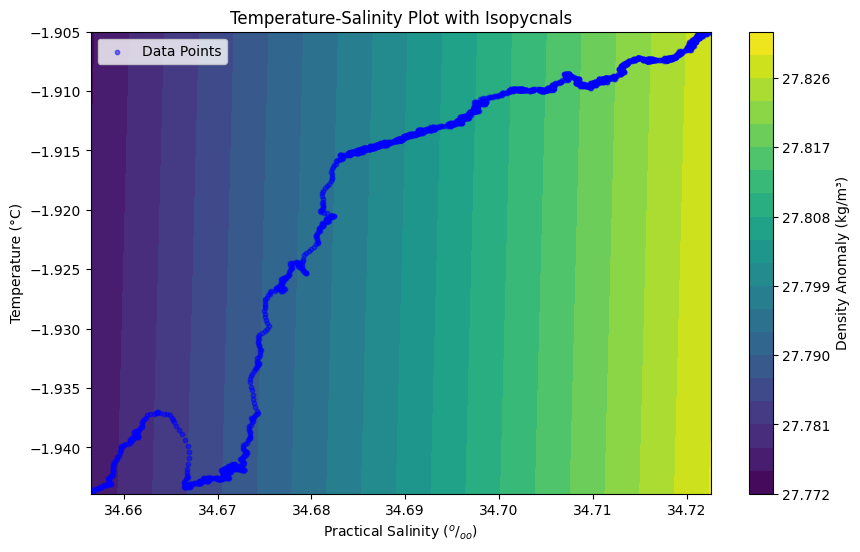

In [8]:
temperature = data['Temperature'].values
practical_salinity = data['SP'].values  # Change to Practical Salinity
pressure = data['Pressure_dbar'].values

# Define T-S grid for isopycnals
temp_range = np.linspace(np.nanmin(temperature), np.nanmax(temperature), 100)
sal_range = np.linspace(np.nanmin(practical_salinity), np.nanmax(practical_salinity), 100)
temp_grid, sal_grid = np.meshgrid(temp_range, sal_range)

# Calculate density (sigma) for the T-S grid at a fixed pressure, say surface (0 dbar)
density_grid = gsw.sigma0(sal_grid, temp_grid)  # Density anomaly (sigma0) at 0 dbar

# Plot
plt.figure(figsize=(10, 6))
contour = plt.contourf(sal_grid, temp_grid, density_grid, levels=20, cmap="viridis")  # Filled contours
plt.colorbar(contour, label='Density Anomaly (kg/m³)')  # Add colorbar for filled contours

# Scatter plot of the data points
plt.scatter(practical_salinity, temperature, c='blue', s=10, alpha=0.5, label="Data Points")  # Added alpha for transparency

# Labels and title
plt.xlabel("Practical Salinity ($^o/_{oo}$)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature-Salinity Plot with Isopycnals")
plt.legend()
plt.show()

In [9]:
time_casts = [pd.to_datetime('2021-11-02 02:57:55', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-02 03:15:55', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-02 03:45:40', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-02 03:45:20', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-02 04:00:00', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-02 04:20:00', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 00:26:55', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 00:45:00', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 01:12:20', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 01:12:00', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 01:23:00', format='%Y-%m-%d %H:%M:%S'),
              pd.to_datetime('2021-11-03 01:39:00', format='%Y-%m-%d %H:%M:%S')]

In [10]:
# evaluate errors
from error_analysis import*

# Example nominal values:
C_Sm = ds.con.data       # conductivity [S/m] (roughly expected at the measurement site;
                # TO-DO: find value from upper ~40 m CTD / mixed; Fig. 7a)
T90_C   = ds.Temperature.data      # in-situ temperature [°C, ITS-90] (from upper ~40 m CTD / mixed; Fig. 7a)

# evaluate the pressure for the instrument depth
from gsw import p_from_z
# camp 2021 coordinates
lon = 166.23333333333332
lat = -77.86666666666666
p_dbar  = p_from_z(-ds.depth.data, lat)     # sea pressure [dbar]

# Instrument 1-sigma uncertainties:
delta_t = 4 # months; calibration date CT 30 June 2021
uC_Sm = 0.0003 + delta_t * 0.0003     # S/m (SBE 19plus data sheet)
uT_C = 0.005 + delta_t * 0.0002   # deg C (SBE 19plus data sheet)
uP_dbar = 0.1*1e-2*ds.Pressure_dbar + 0.02*1e-2*ds.Pressure_dbar + (1/12) * 0.02*1e-2*ds.Pressure_dbar * delta_t  # (SBE19plus data sheet)

if not os.path.exists(path + "Ant2021/Ant2021CTDdata/SBE19plus_cast2_3_errors.nc"):
    res = propagate_uncertainty_eos80(
        C_Sm, T90_C, p_dbar,
        uC_Sm, uT_C, uP_dbar,
        n_samples=5000, seed=123
    )
    res.to_netcdf(path + "Ant2021/Ant2021CTDdata/SBE19plus_cast2_3_errors.nc", engine="netcdf4")
else:
    res = xr.open_dataset(path + "Ant2021/Ant2021CTDdata/SBE19plus_cast2_3_errors.nc", engine="netcdf4")

# set the time coordinate on the simulated errors

In [11]:
res = (
    res.assign_coords(time=("depth_dummy", ds.time.data))
      .swap_dims({"depth_dummy": "time"})
      .drop_vars("depth_dummy")
)
res

<xarray.Dataset> Size: 2MB
Dimensions:    (time: 35196)
Coordinates:
  * time       (time) datetime64[ns] 282kB 2021-11-02T02:57:55 ... 2021-11-03...
    n_samples  int64 8B ...
Data variables:
    SP         (time) float64 282kB ...
    rho        (time) float64 282kB ...
    Tf         (time) float64 282kB ...
    u_SP       (time) float64 282kB ...
    u_Tf       (time) float64 282kB ...
    u_rho      (time) float64 282kB ...

/home/nina/pCloudDrive/DATA/CTD_all_up.png


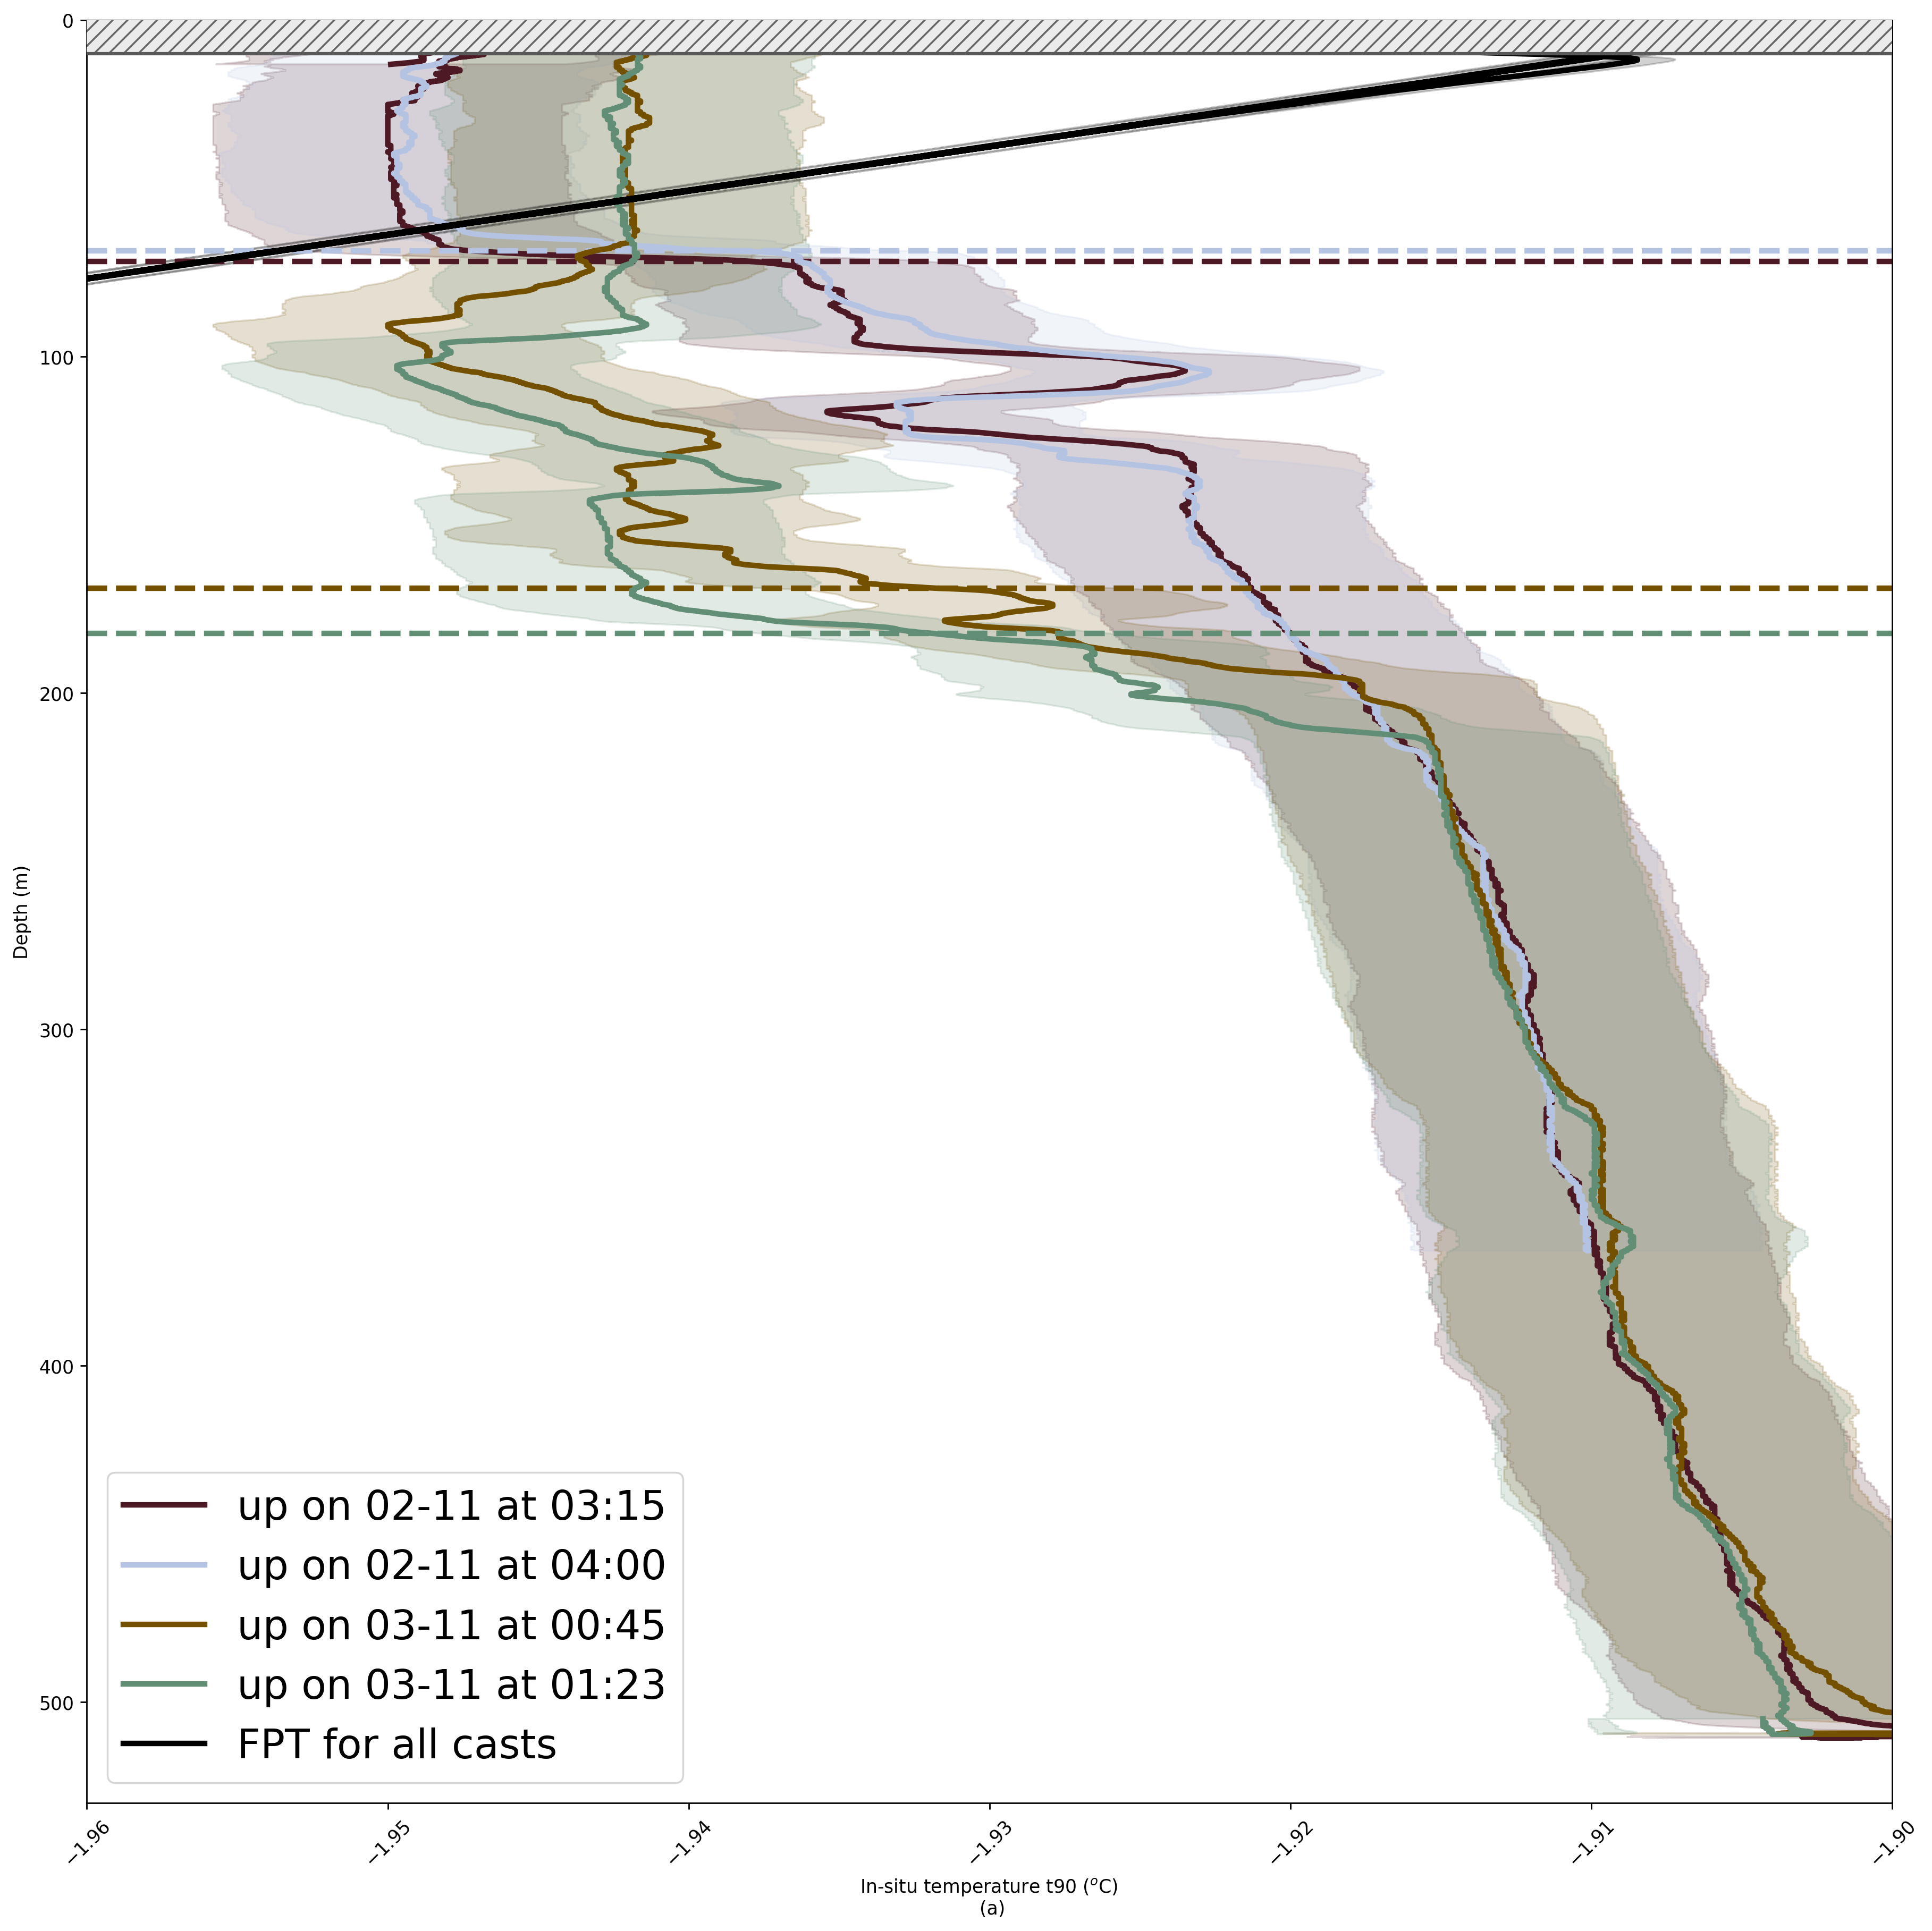

In [12]:
import cmcrameri.cm as cmr

# pick a colour‑blind–friendly map with good contrast on white
cmap = cmr.glasgow   # other solid choices: cmr.batlow, cmr.oslo, cmr.lapaz

cast_indices = list(range(len(time_casts)))[0:-8]
N = len(cast_indices)

# sample N colours from the central range to avoid very light/dark extremes
base_colors = cmap(np.linspace(0.1, 0.92, N))

# (optional) reorder colours to maximize separation between adjacent casts
left, right = 0, N - 1
order = []
while left <= right:
    order.append(left)
    if left != right:
        order.append(right)
    left += 1
    right -= 1
colors = base_colors[order]

fig, ax = plt.subplots(figsize=(15, 15), dpi=250)
ds = ds.assign_coords(depth=("time", ds["depth"].values))
for k, i in enumerate(cast_indices):
    # select upcast
    mid_time = time_casts[i*3 + 1]
    end_time = time_casts[i*3 + 2]
    up_start = mid_time
    up_end = end_time
    time_up = up_start
    up_cast = ds.sel(time=slice(up_start, up_end))
    # Make depth indexable
    # 1) Sort by depth (so the new axis is ordered)
    ds_sorted = up_cast.sortby('depth')
    # 2) Ensure all depths are unique (otherwise swap_dims will fail)
    # Round depths to avoid float jitter from EOS-80 vs TEOS-10
    depth_rounded = np.round(ds_sorted['depth'].values, 3)
    # Get first index of each unique depth (in the sorted depth order)
    _, unique_idx = np.unique(depth_rounded, return_index=True)
    ds_unique = ds_sorted.isel(time=np.sort(unique_idx))
    # 3) Swap the dimension: time -> depth
    ds_depth = ds_unique.swap_dims({'time': 'depth'})
    # discard upper 10m
    ds_below10 = ds_depth.sel(depth=slice(10, None))
    # select depth range
    ds0 = ds_below10.sel(depth=slice(10,20))
    # calculate surface layer temperature
    T0 = ds0.Temperature.mean().data
    # calculate deltaT
    deltaT = abs(ds_below10.Temperature - T0)
    # find deltaT>0.015
    idx = np.argmax(deltaT.data > 0.01)
    fig, ax = plot_up(ds, uT_C, res, fig, ax, mid_time, end_time, color=colors[k])
    ax.axhline(ds_below10.depth[idx], color=colors[k], linestyle = "--", linewidth=3)

# opaque 0–10 m mask

ax.axhspan(0, 10, facecolor="0.92", edgecolor="0.4",
            hatch="///", linewidth=0.0, alpha=1.0, zorder=5)
ax.axhline(y=10, color="0.35", linewidth=1.8, zorder=6)
ax.set_ylim([530, 0])

ax.plot(ds.fp, ds.depth, label="FPT for all casts", color="k", linewidth=3)
ax.fill_betweenx(ds.depth, ds.fp - res.u_Tf, ds.fp + res.u_Tf, alpha=0.18, color="k")
ax.legend()

plt.savefig(savedir+"/CTD_all_up.png",
            bbox_inches="tight")
print(savedir+"/CTD_all_up.png")

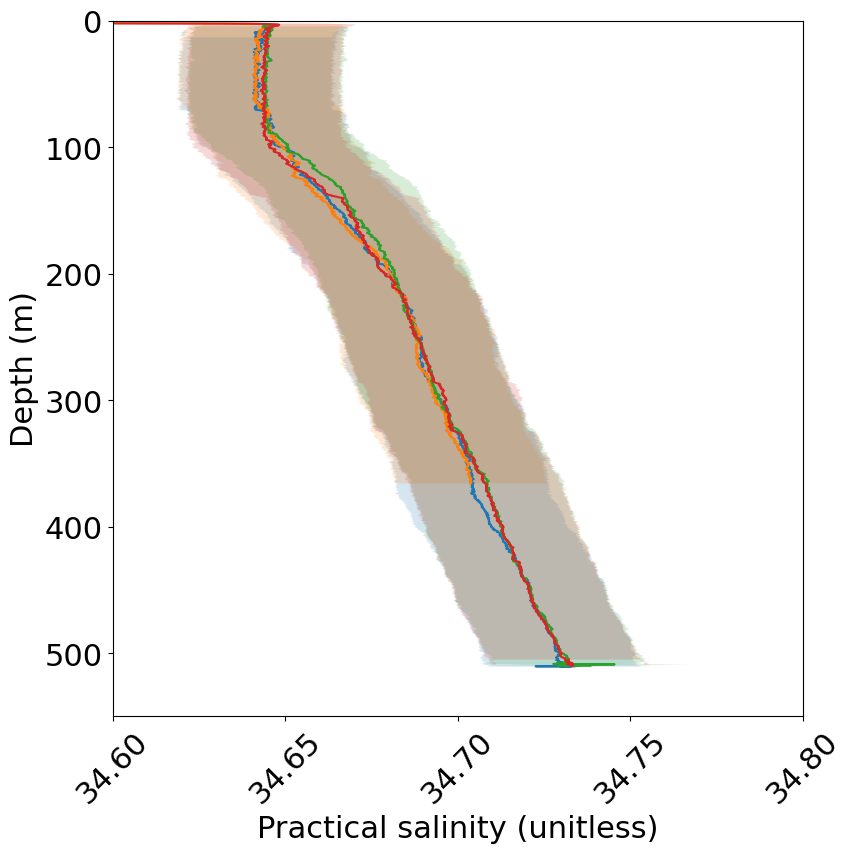

In [13]:
# plot salinity
fig, ax = plt.subplots(1,1, figsize=(9,9))

for i in range(len(time_casts))[0:-8]:
    mid_time = time_casts[i*3+1]
    end_time = time_casts[i*3+2]
    
    up_start = mid_time
    up_end = end_time
    time_up = up_start
    
    up_cast = ds.sel(time=slice(up_start, up_end))
    u_SP = res.sel(time=slice(up_start, up_end)).u_SP.data
    
    ax.plot(
        up_cast.SP,
        up_cast.depth, 
        label="up on " + time_up.strftime("%d-%m") + " at " + time_up.strftime("%H:%M")
    )
    ax.fill_betweenx(up_cast.depth, up_cast.SP - u_SP, up_cast.SP + u_SP, alpha=0.18)
    ax.set_xlim([34.6, 34.8])
    ax.set_ylim([0, 550])
    ax.set_xlabel("Practical salinity (unitless)")
    ax.set_ylabel("Depth (m)")
    ax.invert_yaxis()
    ax.tick_params(axis="x", labelrotation=45)
    # ax.legend(loc="upper right")
    #    ax2.legend()
    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    plt.tight_layout()
    plt.rcParams["font.size"] = 22

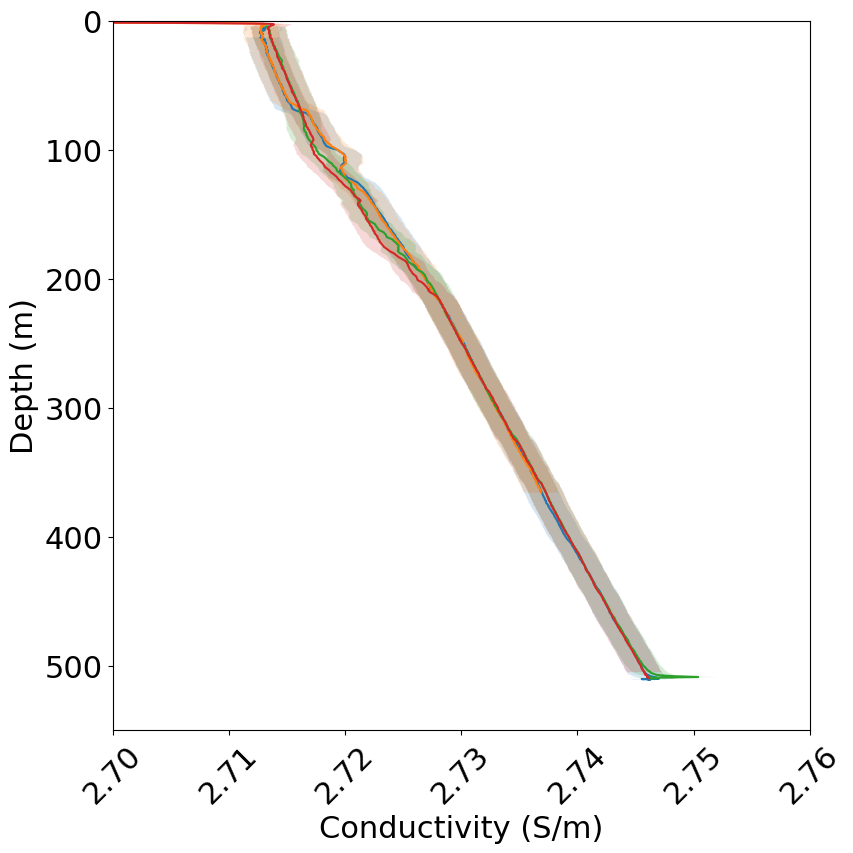

In [14]:
# plot conductivity
fig, ax = plt.subplots(1,1, figsize=(9,9))

for i in range(len(time_casts))[0:-8]:
    mid_time = time_casts[i*3+1]
    end_time = time_casts[i*3+2]
    
    up_start = mid_time
    up_end = end_time
    time_up = up_start
    
    up_cast = ds.sel(time=slice(up_start, up_end))
    
    ax.plot(
        up_cast.con,
        up_cast.depth, 
        label="up on " + time_up.strftime("%d-%m") + " at " + time_up.strftime("%H:%M")
    )
    ax.fill_betweenx(up_cast.depth, up_cast.con - uC_Sm, up_cast.con + uC_Sm, alpha=0.18)
    ax.set_xlim([2.7, 2.76])
    ax.set_ylim([0, 550])
    ax.set_xlabel("Conductivity (S/m)")
    ax.set_ylabel("Depth (m)")
    ax.invert_yaxis()
    ax.tick_params(axis="x", labelrotation=45)
    # ax.legend(loc="upper right")
    #    ax2.legend()
    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    plt.tight_layout()
    plt.rcParams["font.size"] = 22

In [15]:
# calculate the supercooling
# load the filtered data, because we're not analyzing spikes anymore
# ds = xr.open_dataset(path+"Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FALCT_cast2_3.nc", engine="netcdf4")

fp = xr.DataArray(
    eos80.fp(ds.SP, ds.Pressure_dbar),  # ITS90
    dims=["time"],      # Corresponding dimension
    coords={"time": ds.coords["time"]},  # Link to existing coordinates
)
ds["fp"] = fp

SC = xr.DataArray(
    (abs(ds.Temperature)-abs(ds.fp))*1e3,  # Data for the new variable
    dims=["time"],      # Corresponding dimension
    coords={"time": ds.coords["time"]},  # Link to existing coordinates
)
ds["SC"] = SC

# # reopen with supercooling
# ds = xr.open_dataset(path+"Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FALCT_cast3.nc", engine="netcdf4")

os.remove(path+"Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast2_3_SC.nc")
ds.to_netcdf(path+"Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast2_3_SC.nc", engine="netcdf4")

Estimated surface freezing point temperature  [ 0.  0.  0. ... nan nan nan]


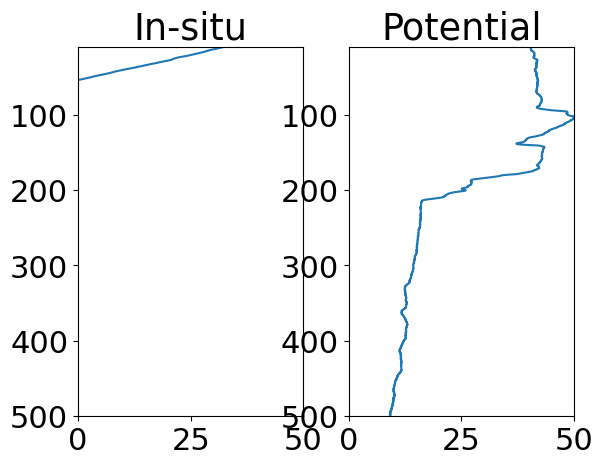

In [16]:
# assume temperature default is in-situ (data headers, nor SBE data processing manual specify this)
lon = 166.2335
lat = -77.8667
t_potential = eos80.ptmp(ds.SP, ds.Temperature, ds.Pressure_dbar)
# calculate depth
depth = -1*gsw.z_from_p(ds.Pressure_dbar, -77.8667)
ds.coords["depth"] = depth
# choose the second cast on 3 Nov to analyze, because it's closest to the Icefin dives
start_time = pd.to_datetime('2021-11-03 01:12:00',
               format='%Y-%m-%d %H:%M:%S')
mid_time = pd.to_datetime('2021-11-03 01:23:00',
               format='%Y-%m-%d %H:%M:%S')
end_time = pd.to_datetime('2021-11-03 01:39:00',
               format='%Y-%m-%d %H:%M:%S')
time_cast = start_time

# select the upcast data
upcast = ds.sel(time=slice(mid_time, end_time))

# calculate the surface freezing point temperature for 0 dbar and salinity averaged between 10 and 30 dbar
fp = eos80.fp(ds.SP, 0) # ITS-90
# calculate the potential supercooling
SC_potential = xr.DataArray(
    (abs(t_potential)-abs(fp))*1e3,  # Data for the new variable
    dims=["time"],      # Corresponding dimension
    coords={"time": ds.coords["time"]},  # Link to existing coordinates
)
ds["SC_potential"] = SC_potential
upcast["SC_potential"] = SC_potential

# plot the insitu supercooling
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.plot(upcast.SC, upcast.Pressure_dbar)
ax1.set_xlim([0,50])
ax1.set_ylim([10,500])
ax1.invert_yaxis()
ax1.set_title("In-situ")

ax2.plot(upcast.SC_potential, upcast.depth)
ax2.set_ylim([10,500])
ax2.set_xlim([0,50])
ax2.invert_yaxis()
ax2.set_title("Potential")
print("Estimated surface freezing point temperature ", fp)

In [17]:
if not ds.SC_potential.mean().data==0:
    ds.to_netcdf(path+"Ant2021/Ant2021CTDdata/SBE19p_Ant2021_FbestALCT_cast2_3_SC.nc", engine="netcdf4")
else:
    print("error saving data")

Estimated surface freezing point temperature  [ 0.  0.  0. ... nan nan nan]
In-situ supercooled layer thickness (m) 53.9
Maximum depth with 40 mK potential SC (m):  <xarray.DataArray 'depth' ()> Size: 8B
array(176.5)
SC at 10 metres depth (mK):  32.772640687840436


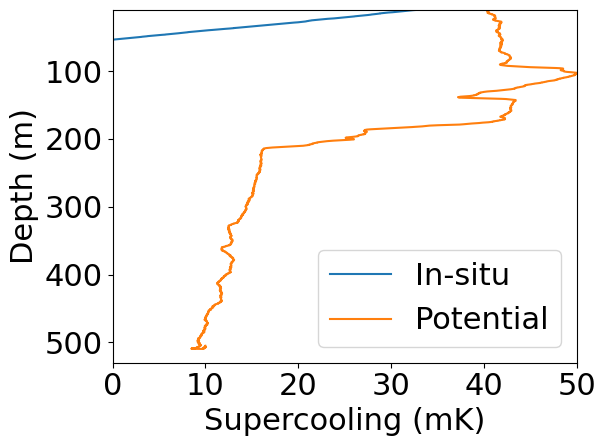

In [18]:
from seawater import dpth
# plot the insitu supercooling
fig, ax = plt.subplots()
ax.plot(upcast.SC, upcast.depth, label = "In-situ")
ax.plot(upcast.SC_potential, upcast.depth, label = "Potential")
ax.set_xlim([0,50])
ax.set_ylim([10,530])
ax.invert_yaxis()
ax.legend(loc="best")
# ax.set_title("Supercooling on "+str(time_cast))
ax.set_xlabel("Supercooling (mK)")
ax.set_ylabel("Depth (m)")
plt.rcParams.update({'font.size': 18}) 
print("Estimated surface freezing point temperature ", fp)
plt.tight_layout()
# find where the insitu SC is zero
print("In-situ supercooled layer thickness (m)", 
      np.round(upcast.depth[np.round(upcast.SC,0)==0].mean(),1).data)
print("Maximum depth with 40 mK potential SC (m): ", 
    np.round(upcast.depth[np.round(upcast.SC_potential,0)==40],1).max())
print("SC at 10 metres depth (mK): ", np.nanmean(upcast.SC.where(np.round(upcast.Pressure_dbar,0)==10)))
# fig.savefig(save_dir+"SC_"+time_cast.strftime('%Y%m%d%H%M')+".png", bbox_inches = "tight")

timing of downcast  2021-11-03 01:17:30


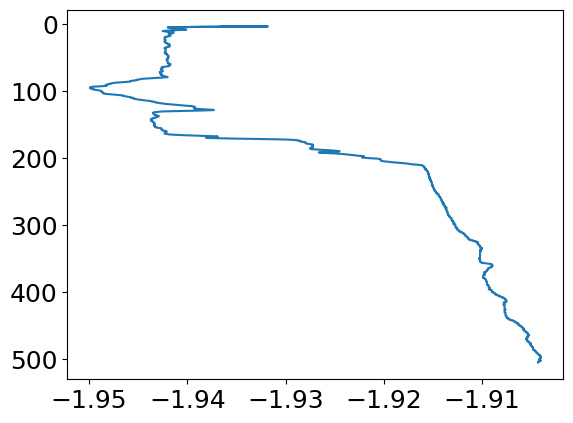

In [19]:
# select the last downcast
video_start_time = "2021-11-03 02:13:07.208928"
sel_start = pd.to_datetime('2021-11-03 01:12:00',
               format='%Y-%m-%d %H:%M:%S')
sel_end = pd.to_datetime('2021-11-03 01:23:00',
               format='%Y-%m-%d %H:%M:%S')
time_down = sel_start+(sel_end-sel_start)/2
print("timing of downcast ", time_down)
last_downcast = ds.sel(time=slice(sel_start, sel_end))
fig,ax = plt.subplots()
ax.plot(last_downcast.Temperature, last_downcast.depth, label = "down")
plt.gca().invert_yaxis()

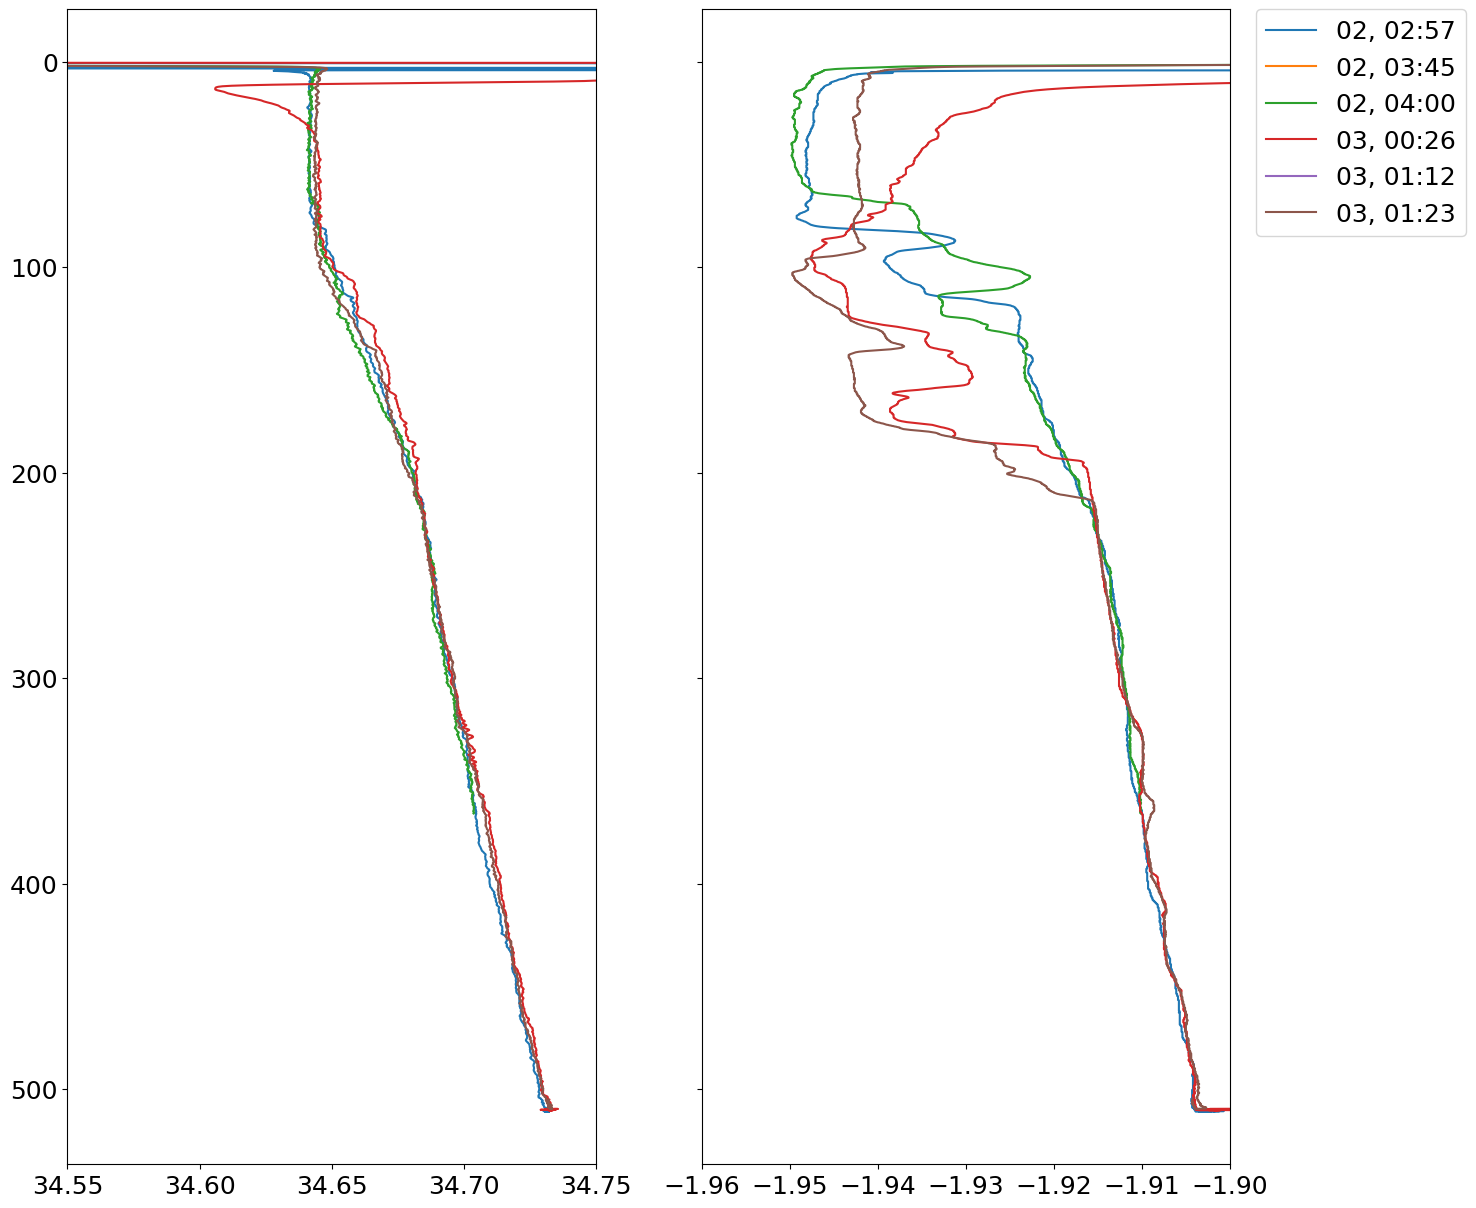

In [20]:
fig, (ax, ax2) = plt.subplots(figsize = (15,15), ncols=2, nrows=1, sharey=True)
for i in np.arange(0, len(time_casts), 2):
    ds_sel = ds.sel(time=slice(time_casts[i], time_casts[i+1]))
    ax.plot(ds_sel.SP, ds_sel.depth, label=pd.to_datetime(time_casts[i]).strftime('%d, %H:%M'))
    ax2.plot(ds_sel.Temperature, ds_sel.depth)
ax.set_xlim([34.55, 34.75])
ax2.set_xlim([-1.96, -1.9])
# ax3.set_xlim([-10, 50])
ax.invert_yaxis()
ax.legend(loc='upper left', bbox_to_anchor=(2.25, 1), borderaxespad=0)
# ax2.invert_yaxis()